In [1]:
#CROP RECOMMENDATION - MODEL DEVELOPMENT
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dataset
df = pd.read_csv("../data/Crop_recommendation.csv")

#Separate features and target
X = df.drop("label", axis=1)
y = df["label"]

#Encode crop labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Dataset shape:", df.shape)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

print("\nCrop classes:")
print(label_encoder.classes_)

Dataset shape: (2200, 8)
Training set: (1760, 7)
Testing set: (440, 7)
Number of classes: 22

Crop classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [2]:
#FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training data shape: (1760, 7)
Scaled testing data shape: (440, 7)


In [3]:
#CREATE BASELINE MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        random_state=42
    ),

    "KNN": KNeighborsClassifier()
}

print("Baseline models created successfully.")

Baseline models created successfully.


In [4]:
#TRAIN BASELINE MODELS
trained_baseline_models = {}

for name, model in baseline_models.items():

    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    trained_baseline_models[name] = model

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.


In [5]:
#IMPORT EVALUATION METRICS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Imported successfully.")

Imported successfully.


In [6]:
#GENERATE PREDICTIONS
baseline_predictions = {}

for name, model in trained_baseline_models.items():

    if name in ["Logistic Regression", "SVM", "KNN"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    baseline_predictions[name] = y_pred

    print(f"{name} predictions generated successfully.")

Logistic Regression predictions generated successfully.
Decision Tree predictions generated successfully.
Random Forest predictions generated successfully.
SVM predictions generated successfully.
KNN predictions generated successfully.


In [7]:
#CALCULATE PERFORMANCE METRICS
baseline_results = []

for name, y_pred in baseline_predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

print("Calculated successfully.")

Calculated successfully.


In [8]:
#MODEL COMPARISON TABLE
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df = baseline_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Baseline Model Comparison:")
display(baseline_results_df.round(4))

Baseline Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM,0.9841,0.9856,0.9841,0.9840
2,Decision Tree,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9795,0.9804,0.9795,0.9793
4,Logistic Regression,0.9727,0.9740,0.9727,0.9725


In [9]:
#DETAILED CLASSIFICATION REPORTS
for name, y_pred in baseline_predictions.items():

    print("\n" + "=" * 54)
    print(name)
    print("=" * 54)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      

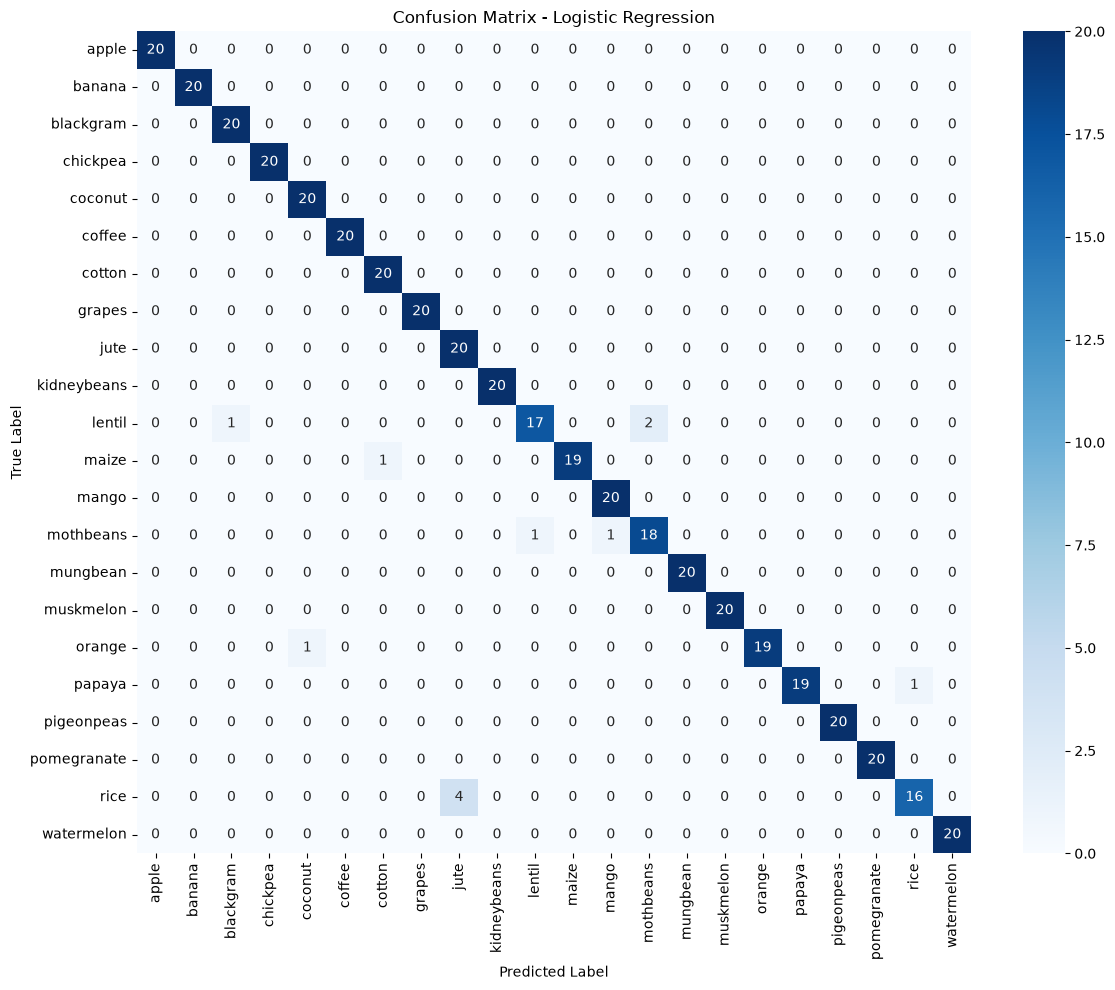

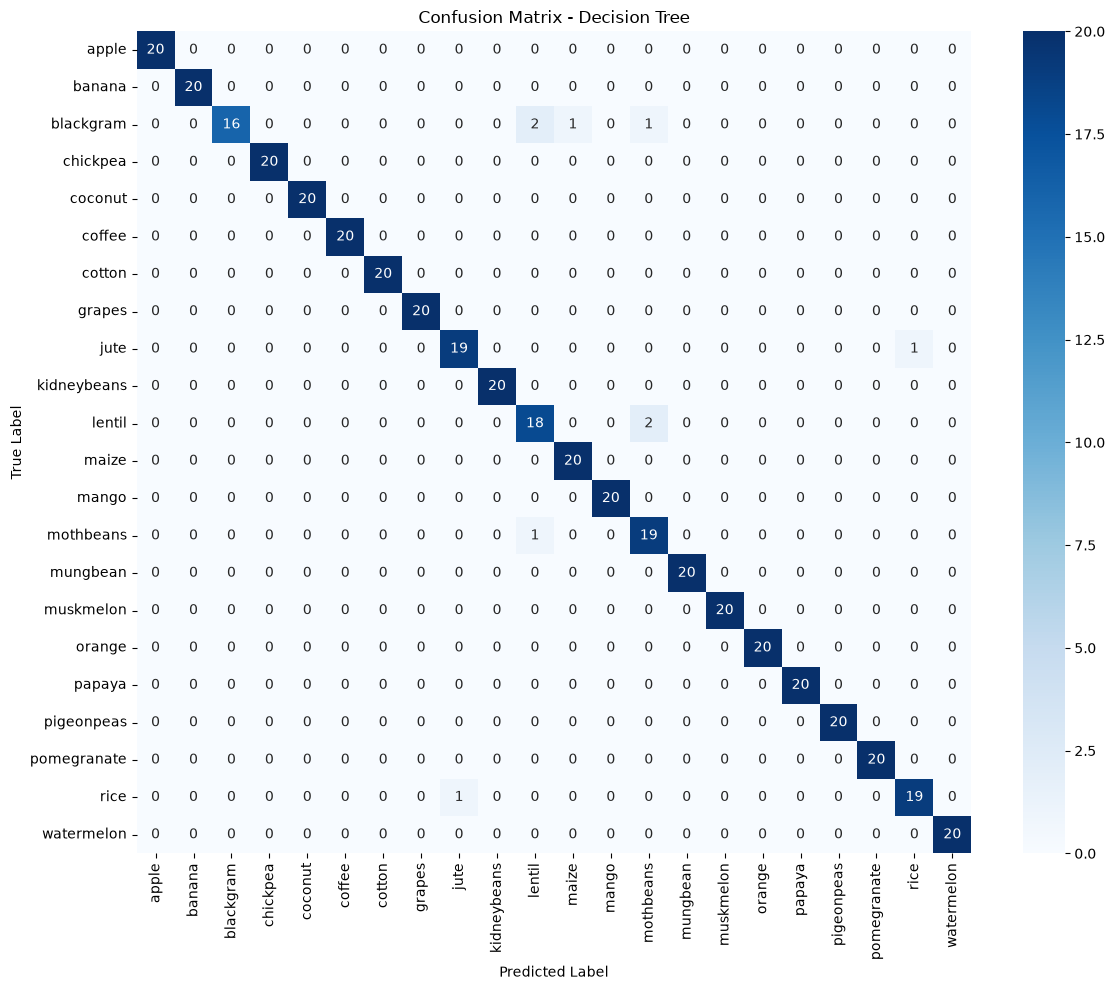

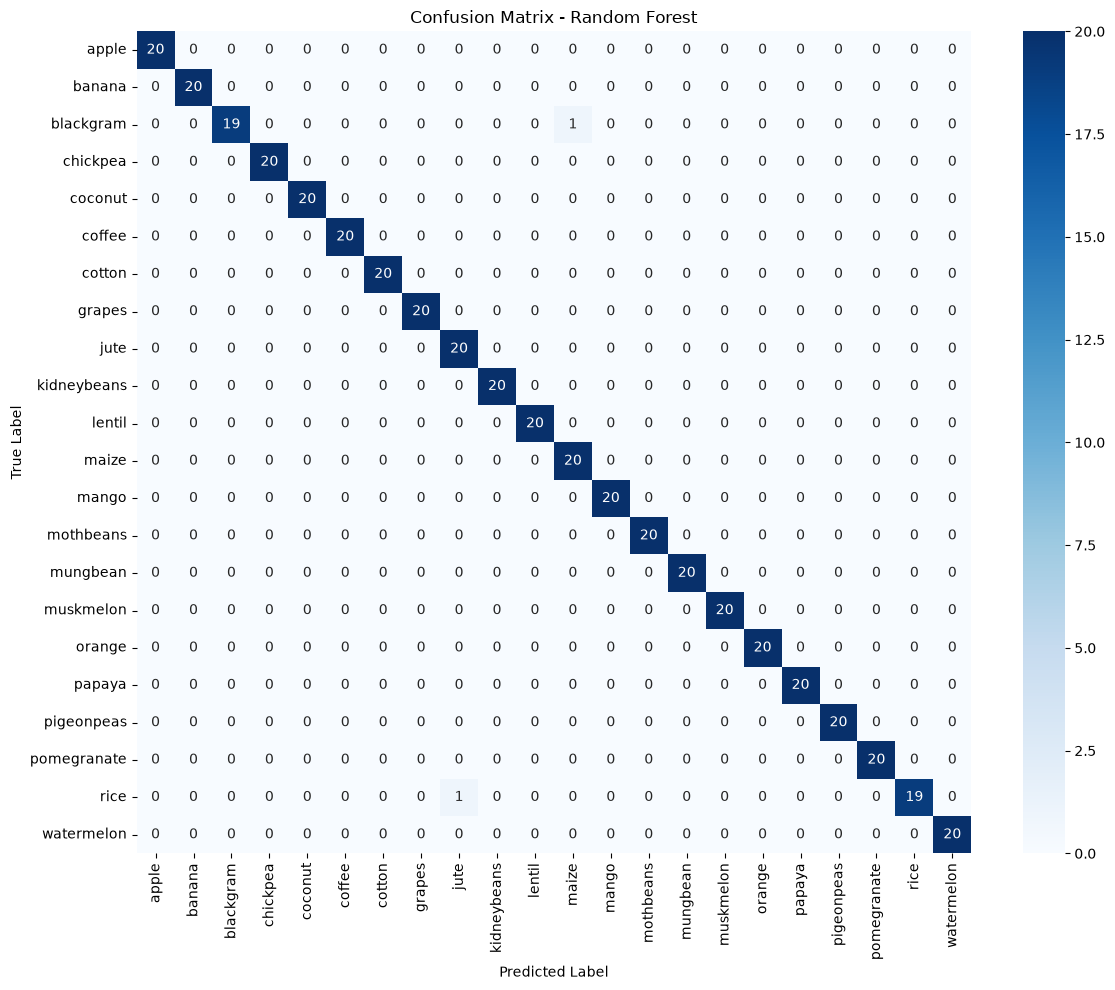

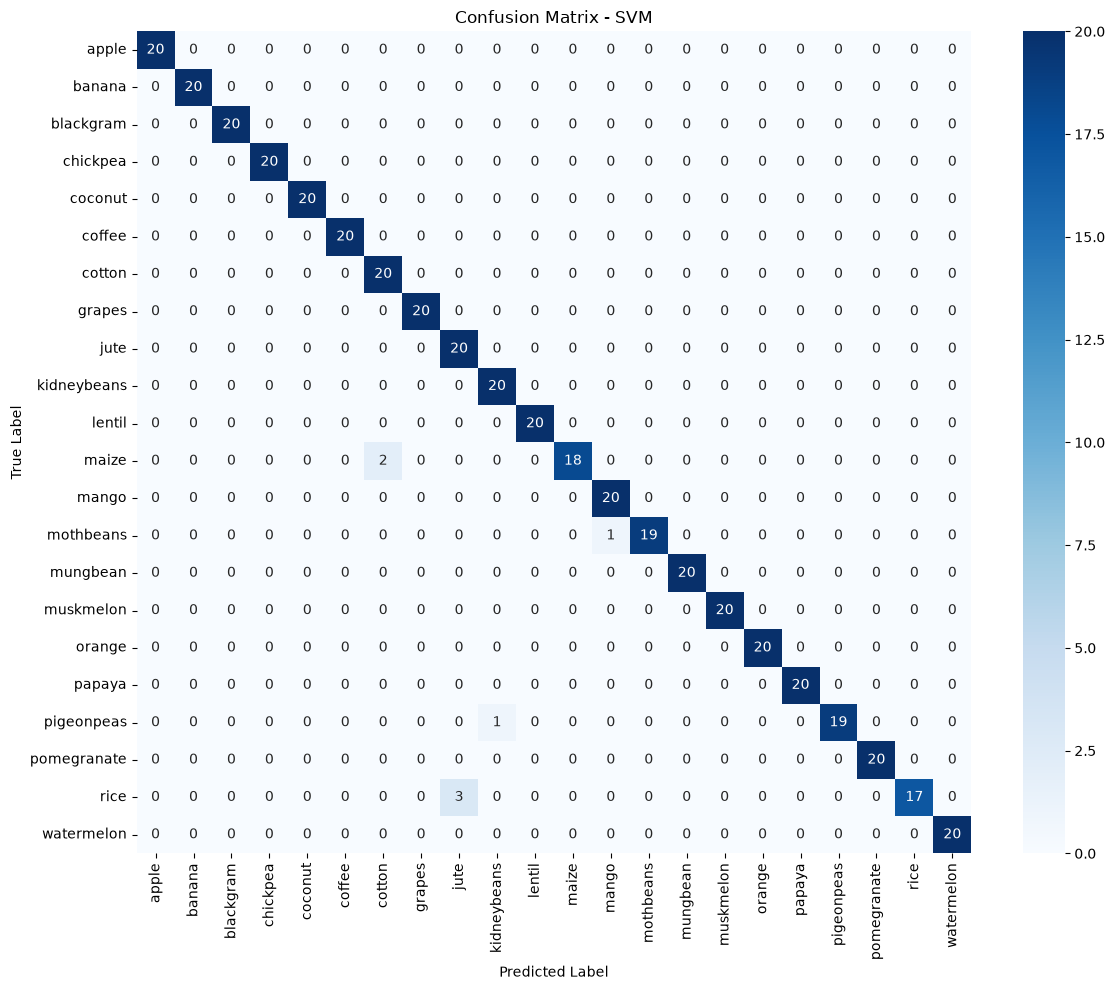

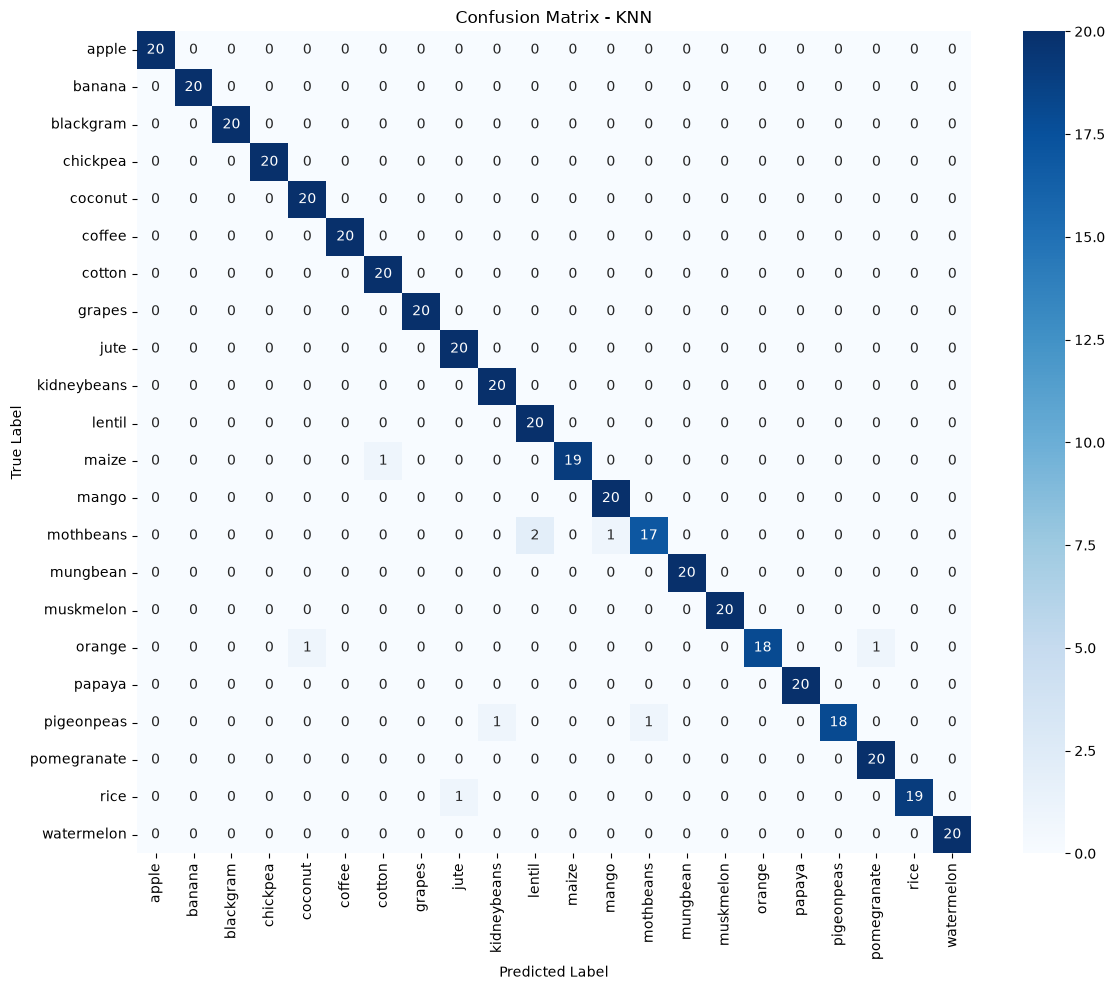

In [10]:
#CONFUSION MATRICES
import matplotlib.pyplot as plt
import seaborn as sns

for name, y_pred in baseline_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [11]:
#PRELIMINARY RESULTS
print("PRELIMINARY RESULTS")
print("=" * 54)

display(baseline_results_df.round(4))

best_baseline_model = baseline_results_df.iloc[0]["Model"]
best_baseline_accuracy = baseline_results_df.iloc[0]["Accuracy"]

print(f"\nBest preliminary model: {best_baseline_model}")
print(f"Accuracy: {best_baseline_accuracy:.4f}")

PRELIMINARY RESULTS


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM,0.9841,0.9856,0.9841,0.9840
2,Decision Tree,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9795,0.9804,0.9795,0.9793
4,Logistic Regression,0.9727,0.9740,0.9727,0.9725



Best preliminary model: Random Forest
Accuracy: 0.9955


In [12]:
#BEST PRELIMINARY MODELS
top_models = baseline_results_df.head(3)

print("Top 3 Preliminary Models:")
display(top_models.round(4))

Top 3 Preliminary Models:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9955,0.9957,0.9955,0.9955
1,SVM,0.9841,0.9856,0.9841,0.9840
2,Decision Tree,0.9795,0.9806,0.9795,0.9794


In [13]:
#DEFINE MODELS FOR CROSS-VALIDATION
from sklearn.pipeline import Pipeline

cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

print("Models defined successfully.")

Models defined successfully.


In [14]:
#CROSS-VALIDATION
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

    print("\n" + "=" * 19)
    print(name)
    print("=" * 19)
    print("Fold Accuracies:", scores)
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")


Logistic Regression
Fold Accuracies: [0.96590909 0.95738636 0.96875    0.97159091 0.97727273]
Mean Accuracy: 0.9682
Standard Deviation: 0.0066

Decision Tree
Fold Accuracies: [0.99431818 0.97727273 0.98863636 0.98863636 0.97727273]
Mean Accuracy: 0.9852
Standard Deviation: 0.0068

Random Forest
Fold Accuracies: [1.         0.99715909 0.98295455 0.99147727 0.99715909]
Mean Accuracy: 0.9938
Standard Deviation: 0.0061

SVM
Fold Accuracies: [0.99147727 0.98295455 0.96306818 0.97159091 0.98579545]
Mean Accuracy: 0.9790
Standard Deviation: 0.0103

KNN
Fold Accuracies: [0.98295455 0.97159091 0.94602273 0.96306818 0.96306818]
Mean Accuracy: 0.9653
Standard Deviation: 0.0121


In [15]:
#CROSS-VALIDATION COMPARISON TABLE
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

print("Cross-Validation Results:")
display(cv_results_df.round(4))

Cross-Validation Results:


,Model,Mean CV Accuracy,Std CV Accuracy
0,Random Forest,0.9938,0.0061
1,Decision Tree,0.9852,0.0068
2,SVM,0.9790,0.0103
3,Logistic Regression,0.9682,0.0066
4,KNN,0.9653,0.0121


In [16]:
#FINAL MODEL SELECTION
best_model_name = cv_results_df.iloc[0]["Model"]
best_cv_accuracy = cv_results_df.iloc[0]["Mean CV Accuracy"]

print("Best Model:", best_model_name)
print(f"Mean CV Accuracy: {best_cv_accuracy:.4f}")

Best Model: Random Forest
Mean CV Accuracy: 0.9938


In [17]:
#FINAL MODEL TRAINING
final_model = cv_models[best_model_name]

final_model.fit(X_train, y_train)

print(f"{best_model_name} trained successfully")

Random Forest trained successfully


In [18]:
#FINAL PREDICTIONS
final_predictions = final_model.predict(X_test)

print("Final predictions generated successfully.")

Final predictions generated successfully.


In [19]:
#FINAL PERFORMANCE EVALUATION
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 24)
print("FINAL MODEL PERFORMANCE")
print("=" * 24)

print(f"Model: {best_model_name}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")

FINAL MODEL PERFORMANCE
Model: Random Forest
Accuracy:  0.9955
Precision: 0.9957
Recall:    0.9955
F1-Score:  0.9955


In [20]:
# FINAL CLASSIFICATION REPORT

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

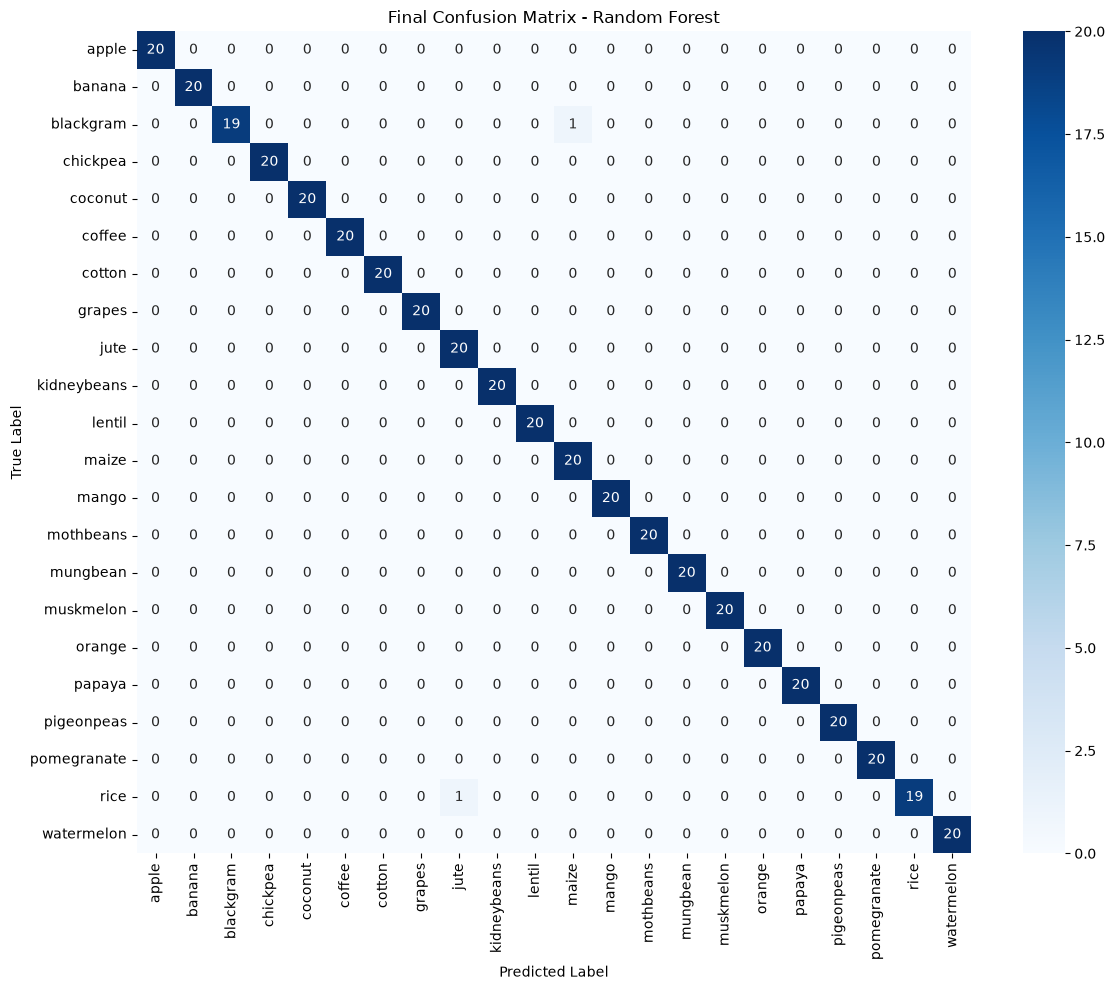

In [21]:
#FINAL CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Final Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
#HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

In [23]:
#PARAMETER GRIDS
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "Decision Tree": {
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf", "linear"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }
}

In [24]:
#GRID SEARCH
tuned_models = {}
tuning_results = []

for name, model in cv_models.items():

    print("\n" + "=" * 26)
    print(f"Tuning {name}")
    print("=" * 26)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    tuned_models[name] = grid_search

    tuning_results.append({
        "Model": name,
        "Best CV Accuracy": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print("Best CV Accuracy:", round(grid_search.best_score_, 4))
    print("Best Parameters:", grid_search.best_params_)


Tuning Logistic Regression
Best CV Accuracy: 0.9778
Best Parameters: {'model__C': 100}

Tuning Decision Tree
Best CV Accuracy: 0.9858
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Tuning Random Forest
Best CV Accuracy: 0.996
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Tuning SVM
Best CV Accuracy: 0.9858
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Tuning KNN
Best CV Accuracy: 0.9756
Best Parameters: {'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'distance'}


In [25]:
#TUNING RESULTS
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Best CV Accuracy",
    ascending=False
).reset_index(drop=True)

display(tuning_results_df.round(4))

,Model,Best CV Accuracy,Best Parameters
0,Random Forest,0.9960,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
1,Decision Tree,0.9858,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
2,SVM,0.9858,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
3,Logistic Regression,0.9778,{'model__C': 100}
4,KNN,0.9756,"{'model__n_neighbors': 5, 'model__p': 1, 'mode..."


In [26]:
#BEST TUNED MODEL
best_tuned_model_name = tuning_results_df.iloc[0]["Model"]
best_tuned_accuracy = tuning_results_df.iloc[0]["Best CV Accuracy"]

best_tuned_search = tuned_models[best_tuned_model_name]

print("=" * 16)
print("BEST TUNED MODEL")
print("=" * 16)

print("Model:", best_tuned_model_name)
print("Best CV Accuracy:", round(best_tuned_accuracy, 4))
print("Best Parameters:")
print(best_tuned_search.best_params_)

BEST TUNED MODEL
Model: Random Forest
Best CV Accuracy: 0.996
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [27]:
#COMPARE BASELINE AND TUNED PERFORMANCE
comparison_df = baseline_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
].copy()

comparison_df = comparison_df.merge(
    cv_results_df[["Model", "Mean CV Accuracy"]],
    on="Model",
    how="left"
)

comparison_df = comparison_df.merge(
    tuning_results_df[["Model", "Best CV Accuracy"]],
    on="Model",
    how="left"
)

comparison_df = comparison_df.sort_values(
    by="Best CV Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Mean CV Accuracy,Best CV Accuracy
0,Random Forest,0.9955,0.9957,0.9955,0.9955,0.9938,0.9960
1,Decision Tree,0.9795,0.9806,0.9795,0.9794,0.9852,0.9858
2,SVM,0.9841,0.9856,0.9841,0.9840,0.9790,0.9858
3,Logistic Regression,0.9727,0.9740,0.9727,0.9725,0.9682,0.9778
4,KNN,0.9795,0.9804,0.9795,0.9793,0.9653,0.9756


In [28]:
#RANDOM FOREST FEATURE IMPORTANCE
best_rf_search = tuned_models["Random Forest"]
best_rf_model = best_rf_search.best_estimator_

print("Best Random Forest Parameters:")
print(best_rf_search.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [29]:
#CALCULATE FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.round(4))

,Feature,Importance
0,rainfall,0.2208
1,humidity,0.2202
2,K,0.1783
3,P,0.1488
4,N,0.1067
5,temperature,0.0746
6,ph,0.0507


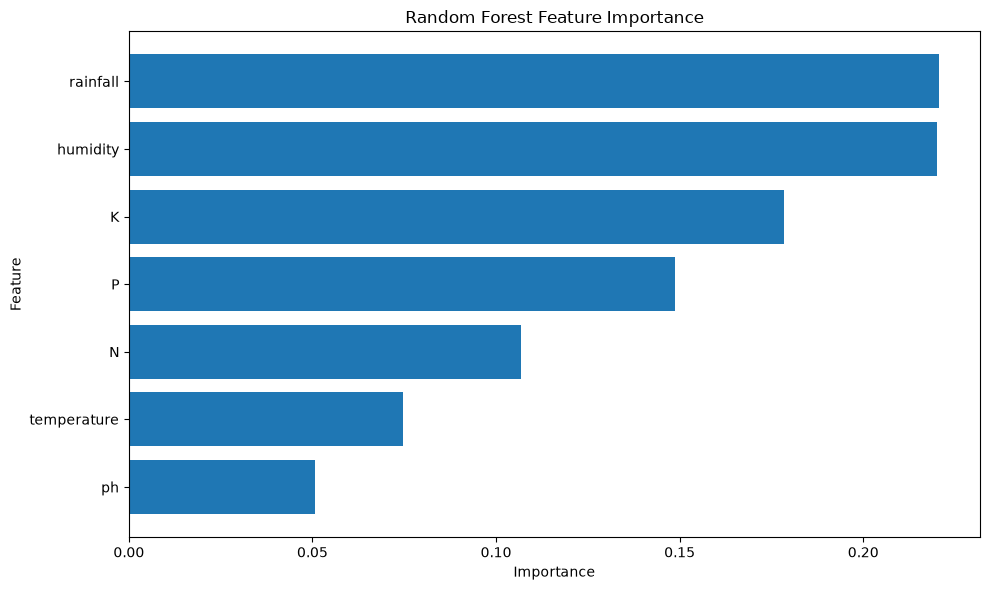

In [30]:
#FEATURE IMPORTANCE PLOT
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
#FINAL MODEL SELECTION
final_model_name = tuning_results_df.iloc[0]["Model"]

final_model = tuned_models[final_model_name].best_estimator_

print("=" * 20)
print("FINAL MODEL SELECTED")
print("=" * 20)

print("Model:", final_model_name)
print("Best CV Accuracy:", round(
    tuned_models[final_model_name].best_score_, 4
))

print("\nBest Parameters:")
print(tuned_models[final_model_name].best_params_)

FINAL MODEL SELECTED
Model: Random Forest
Best CV Accuracy: 0.996

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [32]:
#TRAIN FINAL MODEL ON COMPLETE TRAINING DATA
final_model.fit(X_train, y_train)

print("Trained successfully.")

Trained successfully.


In [33]:
#FINAL PREDICTIONS
final_predictions = final_model.predict(X_test)

print("Generated successfully.")

Generated successfully.


In [34]:
#FINAL MODEL PERFORMANCE
final_accuracy = accuracy_score(y_test, final_predictions)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 24)
print("FINAL MODEL PERFORMANCE")
print("=" * 24)

print("Final Model:", final_model_name)
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")

FINAL MODEL PERFORMANCE
Final Model: Random Forest
Accuracy:  0.9955
Precision: 0.9957
Recall:    0.9955
F1-Score:  0.9955


In [35]:
#FINAL CLASSIFICATION REPORT
print("=" * 27)
print("FINAL CLASSIFICATION REPORT")
print("=" * 27)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20

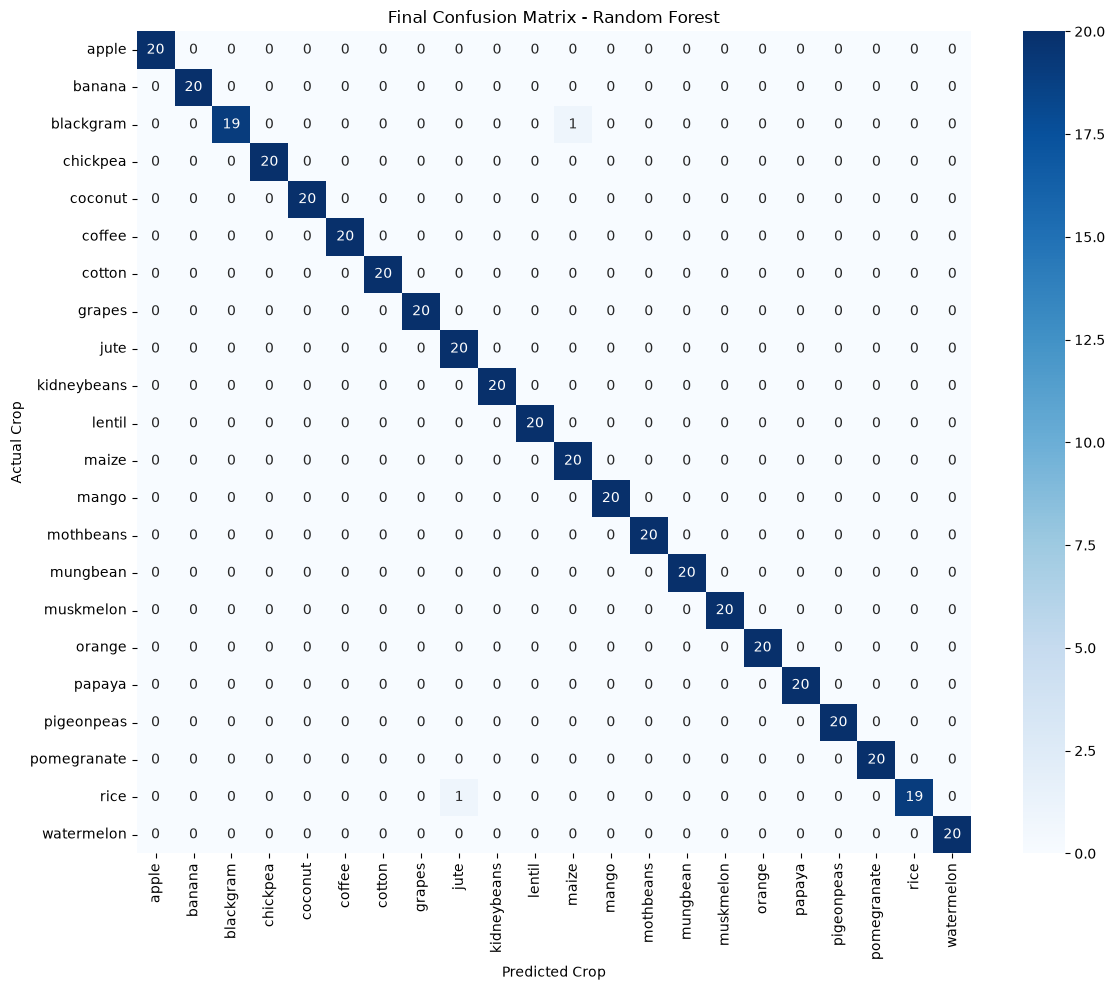

In [36]:
#FINAL CONFUSION MATRIX
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Final Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
#FINAL RESULTS SUMMARY
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print("=" * 22)
print("FINAL RESULTS SUMMARY")
print("=" * 22)

display(final_results.round(4))

FINAL RESULTS SUMMARY


,Metric,Score
0,Accuracy,0.9955
1,Precision,0.9957
2,Recall,0.9955
3,F1-Score,0.9955


In [38]:
#FEATURE NAMES
feature_names = X.columns.tolist()

print("Features used by the model:")
print(feature_names)

Features used by the model:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [39]:
#CROP RECOMMENDATION FUNCTION
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=feature_names
    )

    prediction = final_model.predict(input_data)

    crop = label_encoder.inverse_transform(prediction)[0]

    return crop

In [40]:
#TEST CROP RECOMMENDATION
recommended_crop = recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.8,
    humidity=82,
    ph=6.5,
    rainfall=202
)

print("Recommended Crop:", recommended_crop)

Recommended Crop: rice


In [41]:
#INTERACTIVE CROP RECOMMENDATION SYSTEM
print("=" * 27)
print("CROP RECOMMENDATION SYSTEM")
print("=" * 27)

N = float(input("Enter Nitrogen (N): "))
P = float(input("Enter Phosphorus (P): "))
K = float(input("Enter Potassium (K): "))
temperature = float(input("Enter Temperature (°C): "))
humidity = float(input("Enter Humidity (%): "))
ph = float(input("Enter Soil pH: "))
rainfall = float(input("Enter Rainfall (mm): "))

recommended_crop = recommend_crop(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall
)

print("\n" + "=" * 15)
print("RECOMMENDATION")
print("=" * 15)

print("Recommended Crop:", recommended_crop)

CROP RECOMMENDATION SYSTEM

RECOMMENDATION
Recommended Crop: mango


In [42]:
#SAVE FINAL MODEL
import joblib

joblib.dump(final_model, "../models/final_crop_recommendation_model.pkl")
joblib.dump(label_encoder, "../models/crop_label_encoder.pkl")

print("Saved successfully.")

Saved successfully.
